In [15]:
from sklearn.datasets import load_iris
import pandas as pd

In [16]:
iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [17]:
X = df.drop("target",axis =1)
X.shape

(150, 4)

In [18]:
y=df["target"]

In [19]:
X = df[
    [
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ]
]

print(X.shape)

(150, 4)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(150, 4)


In [21]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components =2
)

In [22]:
X_pca = pca.fit_transform(X_scaled)

In [23]:
print(X_pca.shape)

(150, 2)


In [24]:
print(X_pca[:5])

[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]


In [25]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


In [26]:
print(pca.explained_variance_ratio_.sum())

0.9581320720000166


In [27]:
print("PCA Data:")
print(X_pca[:5])

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca.explained_variance_ratio_.sum())

PCA Data:
[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]

Explained Variance Ratio:
[0.72962445 0.22850762]

Total Explained Variance:
0.9581320720000166


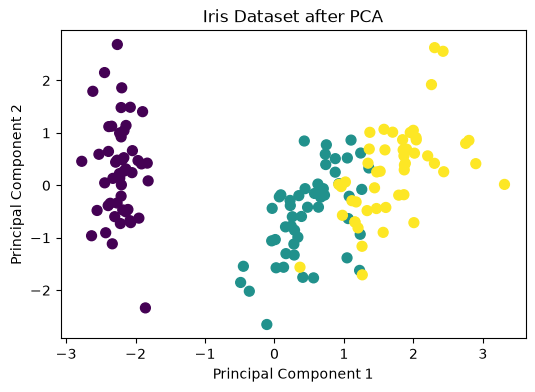

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset after PCA")

plt.show()

In [29]:
print(pca.components_)

[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


In [31]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

print("Explained Variance:")
print(explained_variance)

print("\nCumulative Explained Variance:")
print(explained_variance.cumsum())

Explained Variance:
[0.72962445 0.22850762 0.03668922 0.00517871]

Cumulative Explained Variance:
[0.72962445 0.95813207 0.99482129 1.        ]


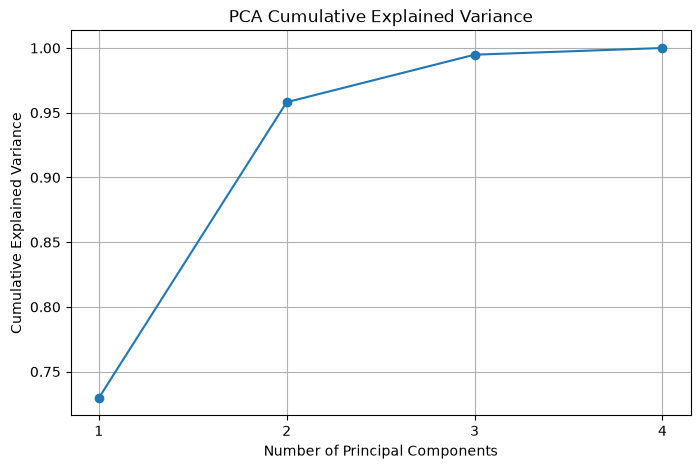

In [32]:
import matplotlib.pyplot as plt

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.xticks(range(1, 5))
plt.grid()

plt.show()